# ChatgaiyyaAlap MT — Day 5 (Google Colab)
Full Evaluation: Aggregate Scoring + Run-to-Run Consistency Check

**Requires Day 1-4 done first.** This notebook pulls from your GitHub repo:
- `outputs/day2_zeroshot_b2c.json` / `day2_zeroshot_c2b.json`
- `outputs/day3_fewshot_b2c.json` / `day3_fewshot_c2b.json`
- `outputs/day4_dictionary_variant.json`

It doesn't re-translate anything except for the consistency check in Step 5, which
deliberately re-runs a subset to test stability.

**Before you start:** `Runtime → Change runtime type → T4 GPU` (only needed for the
consistency-check re-generation in Step 5; everything else is pure aggregation).


## Step 0 — Install dependencies

In [10]:
!pip -q install transformers accelerate sacrebleu pandas tqdm


## Step 2 — Load every technique's results

In [11]:
import json
from pathlib import Path

REQUIRED = [

    "/content/day2_zeroshot_b2c.json",
    "/content/day2_zeroshot_c2b.json",
    "/content/day3_fewshot_b2c.json",
    "/content/day3_fewshot_c2b.json",
    "/content/day4_dictionary_variant.json",
]
missing = [p for p in REQUIRED if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing required Day 2-4 outputs: {missing}. Run those notebooks first "
        f"and make sure each pushed outputs/ to GitHub."
    )

with open("/content/day2_zeroshot_b2c.json", encoding="utf-8") as f:
    day2_b2c = json.load(f)
with open("/content/day2_zeroshot_c2b.json", encoding="utf-8") as f:
    day2_c2b = json.load(f)
with open("/content/day3_fewshot_b2c.json", encoding="utf-8") as f:
    day3_b2c = json.load(f)
with open("/content/day3_fewshot_c2b.json", encoding="utf-8") as f:
    day3_c2b = json.load(f)
with open("/content/day4_dictionary_variant.json", encoding="utf-8") as f:
    day4 = json.load(f)

print("Loaded all technique outputs.")


Loaded all technique outputs.


## Step 3 — Build the aggregate comparison table

Pulls the corpus-level BLEU/chrF each earlier notebook already computed (corpus-level
is the statistically sound metric — sentence-level averages are noisy on short
sentences) into one table across all three techniques and both directions.


In [12]:
import pandas as pd

def metrics_row(direction_label, technique_label, metrics_dict):
    return {
        "direction": direction_label,
        "technique": technique_label,
        "corpus_bleu": metrics_dict.get("corpus_bleu", metrics_dict.get("avg_bleu")),
        "corpus_chrf": metrics_dict.get("corpus_chrf", metrics_dict.get("avg_chrf")),
        "avg_latency_sec": metrics_dict.get("avg_latency_sec"),
    }

rows = [
    metrics_row("B2C", "zero_shot", day2_b2c["metrics"]),
    metrics_row("B2C", "few_shot", day3_b2c["metrics"]),
    metrics_row("B2C", "dictionary", day4["directions"]["bangla_to_chatgaiya"]["metrics"]),
    metrics_row("C2B", "zero_shot", day2_c2b["metrics"]),
    metrics_row("C2B", "few_shot", day3_c2b["metrics"]),
    metrics_row("C2B", "dictionary", day4["directions"]["chatgaiya_to_bangla"]["metrics"]),
]

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df[["direction", "technique", "corpus_bleu", "corpus_chrf", "avg_latency_sec"]]
comparison_df


,direction,technique,corpus_bleu,corpus_chrf,avg_latency_sec
0,B2C,zero_shot,0.0415,0.1389,1.535
1,B2C,few_shot,0.0646,0.2205,1.308
2,B2C,dictionary,0.3781,0.6096,1.324
3,C2B,zero_shot,0.0469,0.1598,1.116
4,C2B,few_shot,0.0970,0.2578,1.234
5,C2B,dictionary,0.3347,0.5315,1.088


In [ ]:
# Which technique won, per direction, per metric -- useful for the Day 6 writeup
for direction in ["B2C", "C2B"]:
    sub = comparison_df[comparison_df["direction"] == direction]
    best_bleu = sub.loc[sub["corpus_bleu"].idxmax()]
    best_chrf = sub.loc[sub["corpus_chrf"].idxmax()]
    print(f"{direction}: best BLEU  -> {best_bleu['technique']} ({best_bleu['corpus_bleu']})")
    print(f"{direction}: best chrF  -> {best_chrf['technique']} ({best_chrf['corpus_chrf']})")
    print()


B2C: best BLEU  -> dictionary (0.3781)
B2C: best chrF  -> dictionary (0.6096)

C2B: best BLEU  -> dictionary (0.3347)
C2B: best chrF  -> dictionary (0.5315)



## Step 4 — Visualize the comparison

A quick bar chart makes the technique-vs-technique pattern easier to see than the raw
table, and you'll likely want this exact chart (or a version of it) in Day 6.


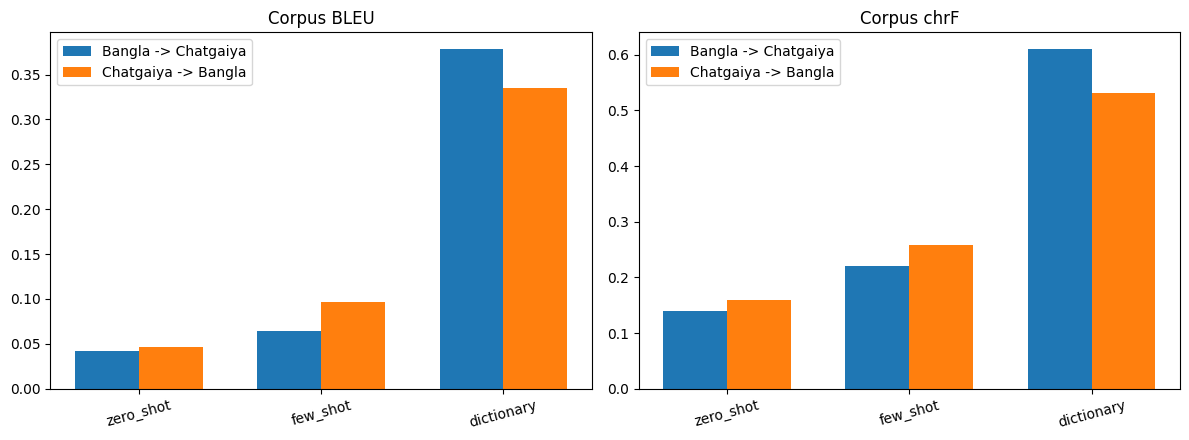

Saved outputs/day5_comparison_chart.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric, title in zip(axes, ["corpus_bleu", "corpus_chrf"], ["Corpus BLEU", "Corpus chrF"]):
    pivot = comparison_df.pivot(index="technique", columns="direction", values=metric)
    pivot = pivot.reindex(["zero_shot", "few_shot", "dictionary"])
    x = np.arange(len(pivot.index))
    width = 0.35
    ax.bar(x - width/2, pivot["B2C"], width, label="Bangla -> Chatgaiya")
    ax.bar(x + width/2, pivot["C2B"], width, label="Chatgaiya -> Bangla")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=15)
    ax.set_title(title)
    ax.legend()
import os
os.makedirs("outputs", exist_ok=True)

plt.savefig("outputs/day5_comparison_chart.png", dpi=150)
plt.tight_layout()
plt.savefig("outputs/day5_comparison_chart.png", dpi=150)
plt.show()
print("Saved outputs/day5_comparison_chart.png")


## Step 5 — Run-to-run consistency check

Tests how stable results are by re-running translation on a subset of sentences
multiple times under two conditions:

1. **Greedy decoding (production config, same as Day 2-4)** — should be fully
   deterministic (identical output every run). Confirming that *is* the finding —
   it's why greedy was chosen for the main runs, for reproducibility.
2. **Temperature sampling** — shows what run-to-run variance actually looks like, for
   contrast, since a fixed sample of your team might reasonably ask "why not sampling?"

Uses a smaller subset (15 sentences) and the zero-shot technique, since this is a
diagnostic check, not another full evaluation pass.


In [15]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import unicodedata, time, statistics
import sacrebleu

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"   # must match Day 2-4

print(f"Loading {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)
model.eval()
print(f"Loaded on device: {device}")


def clean_prediction(text):
    text = text.strip()
    text = text.split("\n")[0].strip()
    text = text.strip("\"'\u201c\u201d\u2018\u2019").strip()
    for prefix in ("Chittagonian:", "Standard Bangla:", "Translation:", "Bangla:"):
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    return unicodedata.normalize("NFC", text)


with open("/content/zero_shot_b2c_v1.txt", encoding="utf-8") as f:
    zero_shot_b2c = f.read()


def translate(text, gen_config):
    prompt_text = zero_shot_b2c.format(text=text)
    messages = [{"role": "user", "content": prompt_text}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, **gen_config)
    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    raw = tokenizer.decode(generated, skip_special_tokens=True).strip()
    return clean_prediction(raw)


Loading Qwen/Qwen2.5-1.5B-Instruct ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded on device: cuda


In [17]:
sample = pd.read_csv("/content/sampled_pairs.csv")
consistency_subset = sample.sample(n=min(15, len(sample)), random_state=7).reset_index(drop=True)

GREEDY_CONFIG = dict(max_new_tokens=80, do_sample=False, repetition_penalty=1.15)
SAMPLING_CONFIG = dict(max_new_tokens=80, do_sample=True, temperature=0.7, repetition_penalty=1.15)

NUM_RUNS = 3

def run_pass(gen_config, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    preds = []
    for _, row in consistency_subset.iterrows():
        preds.append(translate(row["bangla"], gen_config))
    return preds


print("Running greedy consistency check (3 runs)...")
greedy_runs = [run_pass(GREEDY_CONFIG) for _ in range(NUM_RUNS)]

print("Running sampling consistency check (3 runs, temperature=0.7)...")
sampling_runs = [run_pass(SAMPLING_CONFIG, seed=100 + i) for i in range(NUM_RUNS)]


Running greedy consistency check (3 runs)...
Running sampling consistency check (3 runs, temperature=0.7)...


In [18]:
def pct_identical_across_runs(runs):
    """Fraction of sentences where all runs produced the exact same (cleaned) output."""
    n = len(runs[0])
    identical = 0
    for i in range(n):
        outs = {run[i] for run in runs}
        if len(outs) == 1:
            identical += 1
    return round(identical / n, 4)


def bleu_std_across_runs(runs, references):
    """Std deviation of corpus BLEU across the repeated runs -- lower = more stable."""
    scores = []
    for run in runs:
        score = sacrebleu.corpus_bleu(run, [references]).score / 100
        scores.append(score)
    return {
        "per_run_corpus_bleu": [round(s, 4) for s in scores],
        "std_dev": round(statistics.pstdev(scores), 4) if len(scores) > 1 else 0.0,
    }


references = [unicodedata.normalize("NFC", str(r)) for r in consistency_subset["chatgaiya"]]

greedy_identical_pct = pct_identical_across_runs(greedy_runs)
sampling_identical_pct = pct_identical_across_runs(sampling_runs)

greedy_bleu_stats = bleu_std_across_runs(greedy_runs, references)
sampling_bleu_stats = bleu_std_across_runs(sampling_runs, references)

print(f"Greedy decoding   -- identical output across all {NUM_RUNS} runs: {greedy_identical_pct*100:.1f}% of sentences")
print(f"                     corpus BLEU per run: {greedy_bleu_stats['per_run_corpus_bleu']}  (std dev: {greedy_bleu_stats['std_dev']})")
print(f"Sampling (T=0.7)  -- identical output across all {NUM_RUNS} runs: {sampling_identical_pct*100:.1f}% of sentences")
print(f"                     corpus BLEU per run: {sampling_bleu_stats['per_run_corpus_bleu']}  (std dev: {sampling_bleu_stats['std_dev']})")


Greedy decoding   -- identical output across all 3 runs: 100.0% of sentences
                     corpus BLEU per run: [0.0087, 0.0087, 0.0087]  (std dev: 0.0)
Sampling (T=0.7)  -- identical output across all 3 runs: 0.0% of sentences
                     corpus BLEU per run: [0.0092, 0.0092, 0.0073]  (std dev: 0.0009)


## Step 6 — Interpret the consistency result

Read this before writing your own conclusion — don't just copy it, but this is the
shape of the argument the assignment wants:


In [19]:
print(
    "If greedy decoding shows ~100% identical output across runs and ~0 BLEU std dev, "
    "that confirms the production runs (Day 2-4) are fully reproducible -- the same "
    "team member re-running the notebook gets the same numbers, which is exactly why "
    "greedy was used for the scored techniques instead of sampling.\n\n"
    "The sampling condition is expected to show noticeably lower identical-output rate "
    "and a non-zero BLEU std dev across runs. That's not a flaw in the model -- it's "
    "what temperature sampling is *for*. It's included here only to show what "
    "inconsistency would have looked like if the earlier days had used it, and why "
    "corpus-level metrics computed once under sampling would not be reliably "
    "comparable across techniques."
)


If greedy decoding shows ~100% identical output across runs and ~0 BLEU std dev, that confirms the production runs (Day 2-4) are fully reproducible -- the same team member re-running the notebook gets the same numbers, which is exactly why greedy was used for the scored techniques instead of sampling.

The sampling condition is expected to show noticeably lower identical-output rate and a non-zero BLEU std dev across runs. That's not a flaw in the model -- it's what temperature sampling is *for*. It's included here only to show what inconsistency would have looked like if the earlier days had used it, and why corpus-level metrics computed once under sampling would not be reliably comparable across techniques.


## Step 7 — Save `day5_eval.json`

In [20]:
from datetime import datetime, timezone

day5_eval = {
    "dataset": "ChatgaiyyaAlap",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "comparison_table": comparison_df.to_dict(orient="records"),
    "best_technique": {
        "B2C": {
            "by_bleu": comparison_df[comparison_df.direction == "B2C"].loc[
                comparison_df[comparison_df.direction == "B2C"]["corpus_bleu"].idxmax()
            ]["technique"],
            "by_chrf": comparison_df[comparison_df.direction == "B2C"].loc[
                comparison_df[comparison_df.direction == "B2C"]["corpus_chrf"].idxmax()
            ]["technique"],
        },
        "C2B": {
            "by_bleu": comparison_df[comparison_df.direction == "C2B"].loc[
                comparison_df[comparison_df.direction == "C2B"]["corpus_bleu"].idxmax()
            ]["technique"],
            "by_chrf": comparison_df[comparison_df.direction == "C2B"].loc[
                comparison_df[comparison_df.direction == "C2B"]["corpus_chrf"].idxmax()
            ]["technique"],
        },
    },
    "consistency_check": {
        "method": "Repeated (3x) translation of a fixed 15-sentence subset (B2C, zero-shot "
                  "prompt), comparing greedy decoding vs. temperature sampling (T=0.7).",
        "subset_size": len(consistency_subset),
        "num_runs": NUM_RUNS,
        "greedy_decoding": {
            "pct_identical_across_runs": greedy_identical_pct,
            **greedy_bleu_stats,
        },
        "temperature_sampling": {
            "pct_identical_across_runs": sampling_identical_pct,
            **sampling_bleu_stats,
        },
        "conclusion": (
            "Greedy decoding is reproducible run-to-run, which is why it was used for "
            "the scored Day 2-4 comparisons. Temperature sampling introduces real "
            "output variance and would make cross-technique comparisons unreliable "
            "without averaging over many runs per technique."
        ),
    },
    "chart_file": "outputs/day5_comparison_chart.png",
    "notes": [
        "All BLEU/chrF figures here are corpus-level, pulled from Day 2-4 outputs, "
        "which already apply greedy decoding, output cleaning, and NFC Unicode "
        "normalization to avoid measurement-artifact score deflation.",
        "Low absolute scores on this dialect, if still low after those fixes, reflect "
        "genuine difficulty translating into/from a barely-resourced dialect with a "
        "small (1.5B) model, not a scoring bug.",
    ],
}

with open("outputs/day5_eval.json", "w", encoding="utf-8") as f:
    json.dump(day5_eval, f, ensure_ascii=False, indent=2)

print("Saved outputs/day5_eval.json")


Saved outputs/day5_eval.json


---
**Recap — Day 5 checklist:**
1. ✅ Aggregated corpus-level BLEU/chrF across zero-shot, few-shot, and dictionary, both directions
2. ✅ Identified the best-performing technique per direction, per metric
3. ✅ Ran a run-to-run consistency check (greedy vs. sampling), on a fixed subset
4. ✅ Saved `day5_eval.json` and a comparison chart

**Be ready to answer:**
- Which technique actually won, and does that match what you expected going in?
- Did B2C and C2B respond the same way to few-shot/dictionary augmentation, or differently?
- What does the consistency check tell you about how much you should trust a single
  run's scores vs. needing multiple runs?

Next: Day 6 — combine everything into one final comparison table/chart and write your
team's recommendation.
